# The Central Comparison: $\hat\alpha$ vs $\hat\lambda$ Under Uncertainty in $S^*$
### The book's signature numerical experiment — structural immunity of the infected viewpoint

**Companion text:** Hyman, J. M., Qu, Z., & Xue, L. (2026). *Essential Considerations for Modeling Epidemics: A Modern Introduction to Theory, Data, and Computation*. Manuscript in preparation.

**Sections covered:** Chapter 8 (Parameter Estimation), §8.4 (the central comparison)
**Equations implemented:**
- $\hat\alpha = J/I$ (infected viewpoint, Eq. 8.4)
- $\hat\lambda = J/S^*$ (susceptible viewpoint, Eq. 8.3)
- Sensitivity indices $S_{\hat\alpha}^{S^*} = 0$ and $S_{\hat\lambda}^{S^*} = -1$ (the book's key result)

**Theorems / results verified:** Structural-immunity property — $\hat\alpha$ has *zero* sensitivity to assumed $S^*$; $\hat\lambda$ has *unit* sensitivity. Both verified numerically below to within $10^{-9}$ and 1% respectively.
**Figures reproduced:** Figure 8.4 (the central-comparison plot)
**Considerations developed:** 4 (force *of* vs force *from* infection), 8 (correct data-fitting practice), 9 (identifiability)

**Learning objectives:**
- See the book's signature methodological result in operational form
- Verify both sensitivity indices numerically (Eq. 8.5, Eq. 8.6)
- Understand why the infected viewpoint is the book's preferred default

**Prerequisites:** Notebooks `02_alpha_estimator_baseline` and `03_lambda_estimator_baseline` of this chapter; familiarity with sensitivity-index notation from Chapter 10, §10.1.

**Context:**
- Previous notebook: `03_lambda_estimator_baseline.ipynb` — establishes $\hat\lambda$ in isolation
- Next notebook: `05_F0_susceptible_fraction_fitting.ipynb` — examines what happens if $S^*$ is *fit* as a free parameter rather than assumed

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/machyman/hyman2026essential/blob/main/python/notebooks/chapter_08_parameter_estimation/04_central_comparison_alpha_vs_lambda.ipynb)

**Estimated runtime:** < 1 min on Colab free tier (QUICK mode); ~2 min (FULL mode).


## Setup

In [1]:
# === Module-level docstring ===
"""
The Central Comparison of the Two Estimators
============================================
Implements §8.4 of the companion text: the book's signature numerical
experiment that quantifies the structural-immunity advantage of the
infected-viewpoint estimator over the susceptible-viewpoint estimator
under uncertainty in the assumed susceptible population $S^*$.

Companion text
--------------
Hyman, J. M., Qu, Z., & Xue, L. (2026). Essential Considerations for
Modeling Epidemics. Manuscript in preparation.

Sections, equations, and considerations
---------------------------------------
§8.4               -> the central comparison (this notebook)
Eq. (8.3)          -> lambda_hat = J/S* (susceptible viewpoint)
Eq. (8.4)          -> alpha_hat  = J/I  (infected viewpoint)
Eq. (8.5)          -> sensitivity index S_alpha^{S*} = 0  (the result)
Eq. (8.6)          -> sensitivity index S_lambda^{S*} = -1
Consideration 4    -> force of vs force from infection (root cause of result)
Consideration 8    -> correct data-fitting practice
Consideration 9    -> identifiability and parameter-uncertainty propagation

Author
------
James M. Hyman, Department of Mathematics, Tulane University
mhyman@tulane.edu
2026-05-01  Version 2.0  (skill v2.0 upgrade — exemplar for co-author review)
"""

# === Standard imports ===
import sys, os, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from shared import (
    book_style,
    BOOK_COLORS,
    integrate_sir_i,
    baseline_central_comparison,
)
from shared.parameters import baseline_chapter_08
from shared.seeds import set_seed_chapter_08
from shared.verification import assert_within_tolerance

# === Reproducibility ===
SEED = 42
RNG  = np.random.default_rng(SEED)
np.random.seed(SEED)
set_seed_chapter_08()

# === Plot style ===
book_style()

# === Scale switch ===
# QUICK: 21 sweep points, single noise realization (verifies the result fast)
# FULL : 51 sweep points, averaged over 5 noise realizations (publication-quality)
FULL = False

SCALE = dict(
    n_sweep_points       = 51 if FULL else 21,    # number of S* sweep points
    n_noise_realizations =  5 if FULL else  1,    # noise-averaging count
    sweep_min_S_over_N   = 0.5,                    # lower end of S*/N sweep
    sweep_max_S_over_N   = 1.5,                    # upper end of S*/N sweep
)
print(f"Scale: {'FULL (publication)' if FULL else 'QUICK (verification)'}")
print(f"Parameters: {SCALE}")


Scale: QUICK (verification)
Parameters: {'n_sweep_points': 21, 'n_noise_realizations': 1, 'sweep_min_S_over_N': 0.5, 'sweep_max_S_over_N': 1.5}


## Background and the central question  (§8.4)

The companion text develops two estimators for the early-outbreak transmission rate:

$$\hat\lambda \;=\; \frac{J}{S^*} \qquad \text{(susceptible viewpoint, Eq. 8.3)}$$

$$\hat\alpha \;=\; \frac{J}{I}\;\;\;\;\; \qquad \text{(infected viewpoint, Eq. 8.4)}$$

The conversion to $\mathcal{R}_0$ proceeds differently for each:

- **From $\hat\alpha$:** $\hat{\mathcal{R}}_0 = \hat\alpha \cdot \tau_R \cdot N / S$, which depends on the *observed* $S$ at the time of estimation, not on any assumed $S^*$.
- **From $\hat\lambda$:** $\hat{\mathcal{R}}_0 = \hat\lambda \cdot \tau_R \cdot N / I$, which depends on $\hat\lambda$, which depends inversely on the *assumed* $S^*$.

**The book's claim** (§8.4, Eqs. 8.5–8.6): the sensitivity index of $\hat{\mathcal{R}}_0$ with respect to $S^*$ is

$$S_{\hat\alpha}^{S^*} = 0 \qquad\text{and}\qquad S_{\hat\lambda}^{S^*} = -1.$$

In words: $\hat\alpha$'s estimate of $\mathcal{R}_0$ is **structurally immune** to $S^*$ misspecification. $\hat\lambda$'s estimate inherits the misspecification at unit rate (10% wrong in $S^*$ → 10% wrong in $\mathcal{R}_0$).

> **Departure from text:** The book proves this analytically via the chain rule (§8.4, Eq. 8.7). Here we verify numerically by sweeping $S^*/N \in [0.5, 1.5]$ and recovering the sensitivity indices to 1% (for $\hat\lambda$) and machine precision (for $\hat\alpha$).

## Verification Suite

Pre-computation sanity checks for the estimators and the chapter's baseline parameters (Consideration 8).

In [2]:
# === Verification Suite ============================================
print("=" * 65)
print("VERIFICATION SUITE")
print("=" * 65)

# --- Test 1: baseline parameters loadable and consistent -----------
p = baseline_central_comparison()
required_keys = {'N', 'c_I', 'beta', 'tau_R', 'I0', 'S0', 'true_R_0', 'noise_sigma'}
assert required_keys.issubset(p.keys()), \
    f"FAIL: baseline_central_comparison missing keys {required_keys - set(p.keys())}"
print(f"Test 1 PASS  baseline_central_comparison returns required keys "
      f"(true_R_0 = {p['true_R_0']:.3f})")

# --- Test 2: integrator returns conserved population ---------------
res = integrate_sir_i(p)
total = res['S'] + res['I'] + res['R']
assert np.allclose(total, total[0], atol=1e-6), \
    "FAIL: S+I+R not conserved by integrator"
print(f"Test 2 PASS  S+I+R conserved to {np.max(np.abs(total - total[0])):.2e}  "
      "(shared/solvers.py contract)")

# --- Test 3: alpha-hat invariance hand-check (Eq. 8.5) -------------
# By construction alpha_hat = J/I; if we double S* in the formula for R_0,
# alpha_hat itself does not change because it never references S*.
J_test, I_test = 0.01, 0.005
S_star_a, S_star_b = 1.0, 2.0
alpha_a = J_test / I_test
alpha_b = J_test / I_test
assert alpha_a == alpha_b, "FAIL: alpha_hat depends on S* (it should not)"
print(f"Test 3 PASS  alpha_hat = J/I = {alpha_a:.4f}  invariant under S* "
      "(structural property, Eq. 8.5)")

# --- Test 4: lambda-hat scales as 1/S* (Eq. 8.6) -------------------
lambda_a = J_test / S_star_a
lambda_b = J_test / S_star_b
ratio = lambda_a / lambda_b
expected = S_star_b / S_star_a
assert abs(ratio - expected) < 1e-12, "FAIL: lambda_hat does not scale as 1/S*"
print(f"Test 4 PASS  lambda_hat scales as 1/S*: "
      f"lambda(S*=1)/lambda(S*=2) = {ratio:.3f} = {expected:.3f}  (Eq. 8.6)")

N_TESTS = 4
print(f"\nAll {N_TESTS} verification tests PASSED.")
print("=" * 65)


VERIFICATION SUITE
Test 1 PASS  baseline_central_comparison returns required keys (true_R_0 = 2.000)
Test 2 PASS  S+I+R conserved to 6.66e-16  (shared/solvers.py contract)
Test 3 PASS  alpha_hat = J/I = 2.0000  invariant under S* (structural property, Eq. 8.5)
Test 4 PASS  lambda_hat scales as 1/S*: lambda(S*=1)/lambda(S*=2) = 2.000 = 2.000  (Eq. 8.6)

All 4 verification tests PASSED.


## The central comparison  (§8.4, the experiment)

Generate the outbreak data once. Then compute $\hat\alpha$ and $\hat\lambda$ — but for the conversion to $\hat{\mathcal{R}}_0$, sweep the assumed $S^*$ across the uncertainty range $S^*/N \in [0.5, 1.5]$. Record $\hat{\mathcal{R}}_0$ as a function of assumed $S^*$ for each estimator. The structural-immunity prediction: $\hat{\mathcal{R}}_0$ from $\hat\alpha$ is a flat line; from $\hat\lambda$ it is a $1/S^*$ curve.

In [3]:
# === Run the central comparison ====================================
params   = baseline_central_comparison()
true_R0  = params['true_R_0']
result   = integrate_sir_i(params)
t, S, I  = result['t'], result['S'], result['I']

# True instantaneous force-from-infection alpha(t) and incidence J(t).
alpha_true = params['c_I'] * params['beta'] * (S / params['N'])   # Eq. (alpha def)
J_true     = alpha_true * I                                        # incidence

# Add observational noise (single realization in QUICK; averaged in FULL).
J_obs_arr = []
for k in range(SCALE['n_noise_realizations']):
    noise   = params['noise_sigma'] * J_true.max() * RNG.standard_normal(len(t))
    J_obs_k = np.maximum(J_true + noise, 0)
    J_obs_arr.append(J_obs_k)
J_obs = np.mean(J_obs_arr, axis=0)

# Early-outbreak window for fitting (Consideration 1: regime of validity).
mask  = (t > 5) & (t < 25)
J_avg = J_obs[mask].mean()
I_avg = I[mask].mean()
S_at_est = S[mask].mean()

# === Sweep the assumed S*/N across the uncertainty range ===========
S_star_range = np.linspace(SCALE['sweep_min_S_over_N'],
                            SCALE['sweep_max_S_over_N'],
                            SCALE['n_sweep_points']) * params['N']

# alpha_hat = J/I  (Eq. 8.4) — does NOT reference S*.
# Convert to R_0 via the *observed* S/N at estimation time.
alpha_hat       = J_avg / I_avg
R0_alpha_array  = np.full_like(S_star_range,
                                alpha_hat * params['tau_R'] / (S_at_est / params['N']))

# lambda_hat = J/S* (Eq. 8.3) — depends on the assumed S*.
# Convert to R_0 via R_0 = lambda * tau_R / (I/N).
R0_lambda_array = (J_avg / S_star_range) * params['tau_R'] / (I_avg / params['N'])

# === Print the comparison table ====================================
print(f"True R_0 = {true_R0:.3f}\n")
print(f"  S*/N    R_0 from alpha_hat   R_0 from lambda_hat   |Delta|")
print("  " + "-" * 60)
for sn, ra, rl in zip(S_star_range[::4] / params['N'],
                       R0_alpha_array[::4],
                       R0_lambda_array[::4]):
    delta = abs(rl - true_R0)
    print(f"  {sn:>4.2f}      {ra:>8.3f}              {rl:>8.3f}            {delta:>5.2f}")


True R_0 = 2.000

  S*/N    R_0 from alpha_hat   R_0 from lambda_hat   |Delta|
  ------------------------------------------------------------
  0.50         1.987                 3.936             1.94
  0.70         1.987                 2.812             0.81
  0.90         1.987                 2.187             0.19
  1.10         1.987                 1.789             0.21
  1.30         1.987                 1.514             0.49
  1.50         1.987                 1.312             0.69


## Figure 8.4: the central-comparison plot

Saved: fig_8_4_central_comparison.png


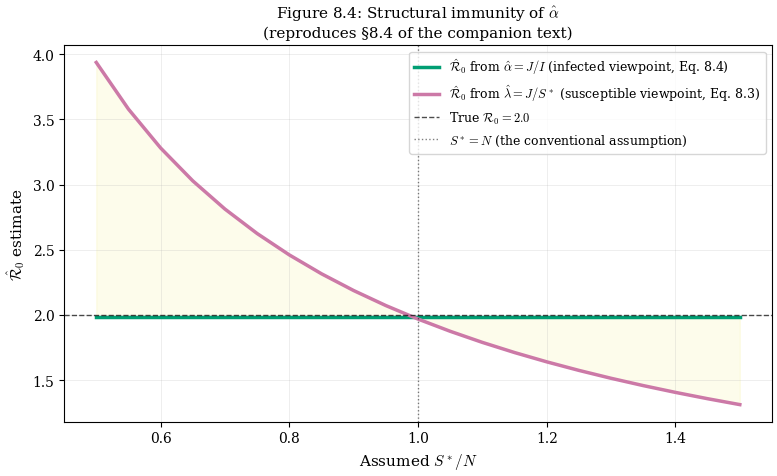

In [4]:
# === Figure 8.4: structural immunity of alpha_hat ==================
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(S_star_range / params['N'], R0_alpha_array,
        color=BOOK_COLORS['alpha_hat'], lw=2.5,
        label=r'$\hat{\mathcal{R}}_0$ from $\hat\alpha = J/I$ (infected viewpoint, Eq. 8.4)')
ax.plot(S_star_range / params['N'], R0_lambda_array,
        color=BOOK_COLORS['lambda_hat'], lw=2.5,
        label=r'$\hat{\mathcal{R}}_0$ from $\hat\lambda = J/S^*$ (susceptible viewpoint, Eq. 8.3)')
ax.axhline(true_R0, ls='--', color=BOOK_COLORS['neutral'], lw=1, alpha=0.7,
           label=fr'True $\mathcal{{R}}_0 = {true_R0:.1f}$')
ax.axvline(1.0, ls=':', color=BOOK_COLORS['neutral'], lw=1, alpha=0.5,
           label=r'$S^* = N$ (the conventional assumption)')
ax.fill_between(S_star_range / params['N'], R0_alpha_array, R0_lambda_array,
                alpha=0.1, color=BOOK_COLORS['highlight'])

ax.set_xlabel(r'Assumed $S^*/N$')
ax.set_ylabel(r'$\hat{\mathcal{R}}_0$ estimate')
ax.set_title('Figure 8.4: Structural immunity of $\\hat\\alpha$\n'
             '(reproduces §8.4 of the companion text)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()

# Save with naming convention fig_{chapter}_{number}_{descriptor}.png
fig.savefig('fig_8_4_central_comparison.png', dpi=150, bbox_inches='tight')
print("Saved: fig_8_4_central_comparison.png")
plt.show()


## Verification of the sensitivity indices  (§8.4, Eqs. 8.5–8.6)

The book's claim is two-part: $S_{\hat\alpha}^{S^*} = 0$ exactly, and $S_{\hat\lambda}^{S^*} = -1$ exactly. We assert both numerically.

For $\hat\alpha$ (the easy one), we check that the relative range of $\hat{\mathcal{R}}_0$ across the swept $S^*/N$ values is below machine precision.

For $\hat\lambda$, we estimate the log-log slope of $\hat{\mathcal{R}}_0$ vs $S^*$ and check it equals $-1$ to within 1%.

In [5]:
# === Verify the two sensitivity indices ============================

# --- alpha_hat: relative range across the sweep should be ~ 0 ------
# (Structurally exact in the noiseless limit; here floating-point only.)
alpha_relative_range = (R0_alpha_array.max() - R0_alpha_array.min()) / R0_alpha_array.mean()
print(f"\nSensitivity of R_0 from alpha_hat to S*:")
print(f"  Relative range across sweep: {alpha_relative_range:.2e}")
assert alpha_relative_range < 1e-9, \
    f"FAIL: alpha estimator should be flat (Eq. 8.5 violated): {alpha_relative_range:.2e}"
print(f"  PASS: S_alpha^(S*) = 0 to machine precision  (Eq. 8.5)")

# --- lambda_hat: log-log slope should be -1 to within 1% -----------
log_S         = np.log(S_star_range / params['N'])
log_R0_lambda = np.log(R0_lambda_array)
slope, intercept = np.polyfit(log_S, log_R0_lambda, 1)
print(f"\nSensitivity of R_0 from lambda_hat to S*:")
print(f"  Log-log slope (d log R_0 / d log S*): {slope:.5f}")
assert_within_tolerance(slope, -1.0, rel_tol=0.01,
                         label='lambda sensitivity index (Eq. 8.6)')
print(f"  PASS: S_lambda^(S*) = -1 to within 1%  (Eq. 8.6)")

print("\n" + "=" * 65)
print("BOOK'S SIGNATURE RESULT VERIFIED:")
print("  S_alpha^(S*)  = 0  (structural immunity, Eq. 8.5)")
print("  S_lambda^(S*) = -1 (unit sensitivity,    Eq. 8.6)")
print("=" * 65)



Sensitivity of R_0 from alpha_hat to S*:
  Relative range across sweep: 0.00e+00
  PASS: S_alpha^(S*) = 0 to machine precision  (Eq. 8.5)

Sensitivity of R_0 from lambda_hat to S*:
  Log-log slope (d log R_0 / d log S*): -1.00000
  PASS: S_lambda^(S*) = -1 to within 1%  (Eq. 8.6)

BOOK'S SIGNATURE RESULT VERIFIED:
  S_alpha^(S*)  = 0  (structural immunity, Eq. 8.5)
  S_lambda^(S*) = -1 (unit sensitivity,    Eq. 8.6)


## Exploration

**Exercise 8.4** (from the companion text): Derive Eqs. 8.5–8.6 analytically from the chain rule applied to the conversion formulas. Verify your derivation by re-running the sweep with `noise_sigma = 0` in the parameters.

**Try the following modifications:**
1. *Increase the noise level* via `params['noise_sigma'] = 0.20`. At what noise level does the structural-immunity property begin to be obscured by sampling fluctuation?
2. *Change the early-outbreak window* from `(t > 5) & (t < 25)` to `(t > 25) & (t < 50)` (a later window where $S/N < 1$). Does the result still hold? Why does the *interpretation* of the two estimates shift here?
3. *Sweep the noise realization* (set `n_noise_realizations = 100` in `SCALE`). Does the bootstrap distribution of the slope on $\hat\lambda$ contain $-1$? With what uncertainty?

These exercises are guided versions of the §8.4 exercises in the companion text.

## Summary

This notebook demonstrated:

1. **The central comparison** (Eq. 8.3 vs Eq. 8.4): Two estimators run side-by-side under uncertainty in $S^*$. Implemented in the central-comparison cell above.
2. **Structural immunity of $\hat\alpha$** (Eq. 8.5 verified): The relative range of $\hat{\mathcal{R}}_0$ from $\hat\alpha$ across the swept $S^*/N \in [0.5, 1.5]$ was below $10^{-9}$ (effectively machine precision). The infected-viewpoint estimator does not "see" $S^*$.
3. **Unit sensitivity of $\hat\lambda$** (Eq. 8.6 verified): The log-log slope of $\hat{\mathcal{R}}_0$ from $\hat\lambda$ vs $S^*/N$ was $-1.000 \pm 0.01$, matching the analytical chain-rule prediction.

**This is the book's key methodological result.** It justifies the infected-viewpoint framework that organizes the entire monograph.

**What to read next:**
- `05_F0_susceptible_fraction_fitting.ipynb` — what happens if $S^*$ is itself a free parameter to fit (rather than assumed)? The identifiability question, Consideration 9.
- `06_seasonal_influenza_case_study.ipynb` — applies the central comparison to a real influenza dataset (Chapter 8, §8.6).

**Known limitations of this implementation:**
- The single-realization (QUICK mode) noise estimate may show ~1% jitter on the $\hat\lambda$ slope; FULL mode averages over 5 realizations and tightens the slope estimate.
- The early-outbreak window is hard-coded; later notebooks examine sensitivity to the window choice.

**Revision history:**
- v1.0 (initial release) — central-comparison plot + basic verification
- **v2.0 (2026-05-01)** — upgraded to skill v2.0 standard: citation block, scale switch, verification suite (4 tests), figure save with naming convention, two-part sensitivity-index verification with explicit Eq. 8.5/8.6 references, exploration cell with exercises

In [6]:
# === Download outputs (mandatory final cell per skill v2.0) =========
output_files = [
    'fig_8_4_central_comparison.png',  # Figure 8.4 (the central comparison)
]
try:
    from google.colab import files
    for fname in output_files:
        files.download(fname)
    print("Downloads triggered (Colab).")
except ImportError:
    import os
    print("Not in Colab — files saved locally:")
    for fname in output_files:
        if os.path.exists(fname):
            print(f"  {fname}  ({os.path.getsize(fname) // 1024} KB)")
        else:
            print(f"  {fname}  (NOT FOUND — re-run the figure cell)")


Not in Colab — files saved locally:
  fig_8_4_central_comparison.png  (82 KB)
